In [11]:
from sklearn.datasets import load_breast_cancer
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import pandas as pd

# การใช้ข้อมูลของ load_breast_cancer
- class malignant --> เป็นมะเร็งร้ายแรง มีค่าเป็น 0
- class benign --> ไม่ร้ายแรง มีค่าเป็น 1

In [11]:
data = load_breast_cancer()
x = data.data
y = data.target
print(data.target_names)

['malignant' 'benign']


# Train Model SVM.SVC and Confusion Metrixs


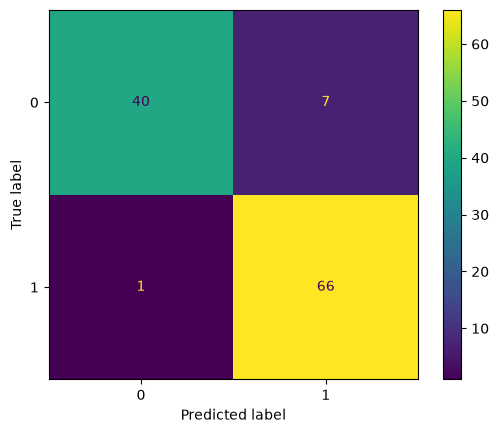

In [12]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0)

model = svm.SVC(kernel='rbf', random_state = 0)
model.fit(x_train, y_train)
pred = model.predict(x_test)

cm = confusion_matrix(y_test, pred, labels = model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = model.classes_)
disp.plot()
plt.show()

# เทียบข้อมูลระหว่าง Ground Truth กับ kernel rbf

In [5]:
for i in range(len(y_test)):
    print(f"i = {i + 1}\t Y_test = {y_test[i]}\t SVM(RBF) = {pred[i]}")

i = 1 	 Y_test = 0	 SVM(RBF) = 1
i = 2 	 Y_test = 1	 SVM(RBF) = 1
i = 3 	 Y_test = 1	 SVM(RBF) = 1
i = 4 	 Y_test = 1	 SVM(RBF) = 1
i = 5 	 Y_test = 1	 SVM(RBF) = 1
i = 6 	 Y_test = 1	 SVM(RBF) = 1
i = 7 	 Y_test = 1	 SVM(RBF) = 1
i = 8 	 Y_test = 1	 SVM(RBF) = 1
i = 9 	 Y_test = 1	 SVM(RBF) = 1
i = 10 	 Y_test = 1	 SVM(RBF) = 1
i = 11 	 Y_test = 1	 SVM(RBF) = 1
i = 12 	 Y_test = 1	 SVM(RBF) = 1
i = 13 	 Y_test = 1	 SVM(RBF) = 1
i = 14 	 Y_test = 1	 SVM(RBF) = 0
i = 15 	 Y_test = 1	 SVM(RBF) = 1
i = 16 	 Y_test = 0	 SVM(RBF) = 0
i = 17 	 Y_test = 1	 SVM(RBF) = 1
i = 18 	 Y_test = 0	 SVM(RBF) = 0
i = 19 	 Y_test = 0	 SVM(RBF) = 0
i = 20 	 Y_test = 0	 SVM(RBF) = 0
i = 21 	 Y_test = 0	 SVM(RBF) = 0
i = 22 	 Y_test = 0	 SVM(RBF) = 0
i = 23 	 Y_test = 1	 SVM(RBF) = 1
i = 24 	 Y_test = 1	 SVM(RBF) = 1
i = 25 	 Y_test = 0	 SVM(RBF) = 0
i = 26 	 Y_test = 1	 SVM(RBF) = 1
i = 27 	 Y_test = 1	 SVM(RBF) = 1
i = 28 	 Y_test = 0	 SVM(RBF) = 1
i = 29 	 Y_test = 1	 SVM(RBF) = 1
i = 30 	 Y_test = 0	 SV

In [14]:
result = pd.DataFrame({
    "ตัวที่" : range(1, len(y_test) + 1),
    "Ground Truth (Target)" : y_test,
    "Kernel rbf" : pred
})
result.set_index("ตัวที่", inplace=True)
print(result)

        Ground Truth (Target)  Kernel rbf
ตัวที่                                   
1                           0           1
2                           1           1
3                           1           1
4                           1           1
5                           1           1
...                       ...         ...
110                         0           0
111                         1           1
112                         0           0
113                         0           0
114                         1           1

[114 rows x 2 columns]


# หาค่า Accuracy

In [6]:
print(f"acc = {accuracy_score(y_test, pred)}") 

acc = 0.9298245614035088


# หาค่า F1_score เปรียบเทียบจาก macro micro
- macro --> ทุก class สำคัญเท่ากันหมด เหมาะกับงานการแพทย์
- micro --> มองภาพรวมทั้งระบบ เหมาะกับงานทั่วไปที่ไม่สนใจความแตกต่างระหว่าง class

In [7]:
print(f"f1_macro = {f1_score(y_test, pred, average='macro')}")
print(f"f1_micro = {f1_score(y_test, pred, average='micro')}") 

f1_macro = 0.9259740259740259
f1_micro = 0.9298245614035088


# หาค่า precission

In [8]:
print(f"precision_macro = {precision_score(y_test, pred, average = 'macro')}")
print(f"precision_micro = {precision_score(y_test, pred, average = 'micro')}")

precision_macro = 0.9398596725693285
precision_micro = 0.9298245614035088


# หาค่า Recall

In [9]:
print(f"Recall_macro = {recall_score(y_test, pred, average='macro')}")
print(f"Recall_micro = {recall_score(y_test, pred, average='micro')}")

Recall_macro = 0.9180692283264529
Recall_micro = 0.9298245614035088
